In [55]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.cluster import KMeans
from sklearn.preprocessing import LabelEncoder
import re

# Set plotting style
sns.set_theme(style="whitegrid")

# 1. Load Data
# filename = '/Users/reamchansovath/Documents/GitHub/datathon-2026/Category B Dataset/sds_datathon_gradsingapore.xlsx'
filename = 'Category B Dataset/sds_datathon_gradsingapore.xlsx'
df = pd.read_excel(filename)

# Standardize Columns
rename_dict = {
    'Response ID': 'id',
    'Time Started': 'start_time',
    'Date Submitted': 'submit_time',
    'Status': 'status',
    'User Agent': 'user_agent',
    'Country': 'country',
    'Which higher education institution do you or did you study at?': 'university',
    'What is your current year of study as of 2025?': 'year',
    'What will be your highest qualification when you graduate?': 'qualification',
    'Which of the following best describes the main subject that you are studying? ': 'subject',
    'Please indicate your nationality.': 'nationality',
    'What is your gender?': 'gender',
    'Which of these statements best describes your current perception of the organisation as an employer?': 'perception',
    'Types of roles available:What do you wish to learn more about regarding the organisation as an employer? (Pick 3)  ': 'info_roles',
    'Career progression and development:What do you wish to learn more about regarding the organisation as an employer? (Pick 3)  ': 'info_career',
    'Compensation and benefits:What do you wish to learn more about regarding the organisation as an employer? (Pick 3)  ': 'info_comp',
    'Work-life balance and culture:What do you wish to learn more about regarding the organisation as an employer? (Pick 3)  ': 'info_culture',
    'Application and interview process:What do you wish to learn more about regarding the organisation as an employer? (Pick 3)  ': 'info_process',
    'Other - Write In (Required):What do you wish to learn more about regarding the organisation as an employer? (Pick 3)  .1': 'info_other_text',
    'On a scale from 1 to 10 (1 – Low, 10 – High), how would you rate the attractiveness of the organisation as an employer?   ': 'attractiveness',
    'Which of these factors would most motivate you to apply for a position at the organisation?  ': 'motivation',
    'Other - Write In (Required):Which of these factors would most motivate you to apply for a position at the organisation?  ': 'motivation_other'
}
df = df.rename(columns=rename_dict)
df

,id,start_time,submit_time,status,Language,SessionID,user_agent,Tags,IP Address,Longitude,...,info_roles,info_career,info_comp,info_culture,info_process,Other - Write In (Required):What do you wish to learn more about regarding the organisation as an employer? (Pick 3),info_other_text,attractiveness,motivation,motivation_other
0,19,2025-09-02 15:03:01,2025-09-02 15:03:40,Partial,English,1756796577_68b696a123dd27.81295289,Mozilla/5.0 (iPhone; CPU iPhone OS 18_6_2 like...,NaN,104.28.119.112,-97.821999,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,20,2025-09-02 15:15:32,2025-09-02 15:16:59,Disqualified,English,1756797328_68b699901c4cf6.89118890,Mozilla/5.0 (Windows NT 10.0; Win64; x64) Appl...,NaN,57.140.24.26,4.344700,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,21,2025-09-02 15:18:01,2025-09-02 15:19:30,Disqualified,English,1756797478_68b69a26c5d785.44808899,Mozilla/5.0 (Windows NT 10.0; Win64; x64) Appl...,NaN,57.140.24.26,4.344700,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,22,2025-09-03 15:25:18,2025-09-03 15:27:05,Complete,English,1756884314_68b7ed5a14f861.00788803,Mozilla/5.0 (Linux; Android 15; K) AppleWebKit...,NaN,119.234.8.156,103.839302,...,Types of roles available,Career progression and development,NaN,NaN,Application and interview process,NaN,NaN,8.0,Meaningful work impact,NaN
4,23,2025-09-03 15:34:31,2025-09-03 15:34:31,Partial,English,1756884864_68b7ef80372683.27687311,Mozilla/5.0 (iPhone; CPU iPhone OS 18_5 like M...,NaN,194.11.199.111,-77.644302,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2609,2628,2025-11-13 11:04:35,2025-11-13 11:31:13,Complete,English,1763003070_69154abe22f171.48493687,Mozilla/5.0 (iPhone; CPU iPhone OS 18_6_2 like...,NaN,111.65.50.67,103.754204,...,Types of roles available,NaN,Compensation and benefits,Work-life balance and culture,NaN,NaN,NaN,7.0,Job security,NaN
2610,2629,2025-11-13 11:16:03,2025-11-13 11:19:03,Complete,English,1763003757_69154d6da70132.86627524,Mozilla/5.0 (iPhone; CPU iPhone OS 18_7 like M...,NaN,119.234.36.66,103.862801,...,NaN,Career progression and development,Compensation and benefits,Work-life balance and culture,NaN,NaN,NaN,7.0,Meaningful work impact,NaN
2611,2630,2025-11-13 13:02:23,2025-11-13 13:02:56,Partial,English,1763009383_6915636777bd07.70179151,Mozilla/5.0 (Linux; Android 10; K) AppleWebKit...,NaN,137.132.26.63,103.763100,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2612,2631,2025-11-13 14:28:12,2025-11-13 14:29:54,Disqualified,English,1763015285_69157a75b57f41.54807902,Mozilla/5.0 (Linux; Android 10; K) AppleWebKit...,NaN,119.234.52.63,103.855400,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [56]:
# Feature Engineering
df['start_time'] = pd.to_datetime(df['start_time'])
df['submit_time'] = pd.to_datetime(df['submit_time'])
df['duration_sec'] = (df['submit_time'] - df['start_time']).dt.total_seconds()
df['is_mobile'] = df['user_agent'].str.contains('Mobile|Android|iPhone', case=False, na=False).astype(int)
df

,id,start_time,submit_time,status,Language,SessionID,user_agent,Tags,IP Address,Longitude,...,info_comp,info_culture,info_process,Other - Write In (Required):What do you wish to learn more about regarding the organisation as an employer? (Pick 3),info_other_text,attractiveness,motivation,motivation_other,duration_sec,is_mobile
0,19,2025-09-02 15:03:01,2025-09-02 15:03:40,Partial,English,1756796577_68b696a123dd27.81295289,Mozilla/5.0 (iPhone; CPU iPhone OS 18_6_2 like...,NaN,104.28.119.112,-97.821999,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,39.0,1
1,20,2025-09-02 15:15:32,2025-09-02 15:16:59,Disqualified,English,1756797328_68b699901c4cf6.89118890,Mozilla/5.0 (Windows NT 10.0; Win64; x64) Appl...,NaN,57.140.24.26,4.344700,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,87.0,0
2,21,2025-09-02 15:18:01,2025-09-02 15:19:30,Disqualified,English,1756797478_68b69a26c5d785.44808899,Mozilla/5.0 (Windows NT 10.0; Win64; x64) Appl...,NaN,57.140.24.26,4.344700,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,89.0,0
3,22,2025-09-03 15:25:18,2025-09-03 15:27:05,Complete,English,1756884314_68b7ed5a14f861.00788803,Mozilla/5.0 (Linux; Android 15; K) AppleWebKit...,NaN,119.234.8.156,103.839302,...,NaN,NaN,Application and interview process,NaN,NaN,8.0,Meaningful work impact,NaN,107.0,1
4,23,2025-09-03 15:34:31,2025-09-03 15:34:31,Partial,English,1756884864_68b7ef80372683.27687311,Mozilla/5.0 (iPhone; CPU iPhone OS 18_5 like M...,NaN,194.11.199.111,-77.644302,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.0,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2609,2628,2025-11-13 11:04:35,2025-11-13 11:31:13,Complete,English,1763003070_69154abe22f171.48493687,Mozilla/5.0 (iPhone; CPU iPhone OS 18_6_2 like...,NaN,111.65.50.67,103.754204,...,Compensation and benefits,Work-life balance and culture,NaN,NaN,NaN,7.0,Job security,NaN,1598.0,1
2610,2629,2025-11-13 11:16:03,2025-11-13 11:19:03,Complete,English,1763003757_69154d6da70132.86627524,Mozilla/5.0 (iPhone; CPU iPhone OS 18_7 like M...,NaN,119.234.36.66,103.862801,...,Compensation and benefits,Work-life balance and culture,NaN,NaN,NaN,7.0,Meaningful work impact,NaN,180.0,1
2611,2630,2025-11-13 13:02:23,2025-11-13 13:02:56,Partial,English,1763009383_6915636777bd07.70179151,Mozilla/5.0 (Linux; Android 10; K) AppleWebKit...,NaN,137.132.26.63,103.763100,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,33.0,1
2612,2631,2025-11-13 14:28:12,2025-11-13 14:29:54,Disqualified,English,1763015285_69157a75b57f41.54807902,Mozilla/5.0 (Linux; Android 10; K) AppleWebKit...,NaN,119.234.52.63,103.855400,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,102.0,1


### CATEGORY 1: Question Optimization

In [57]:
# 1.1 Logic Consistency
logic_df = pd.crosstab(df['year'], df['qualification'])

# 1.2 Correlation/Redundancy
info_cols = ['info_roles', 'info_career', 'info_comp', 'info_culture', 'info_process']
info_data = df[info_cols].notnull().astype(int)
info_corr = info_data.corr()

# 1.3 Other Field Utility
other_usage = df['info_other_text'].notnull().mean() * 100

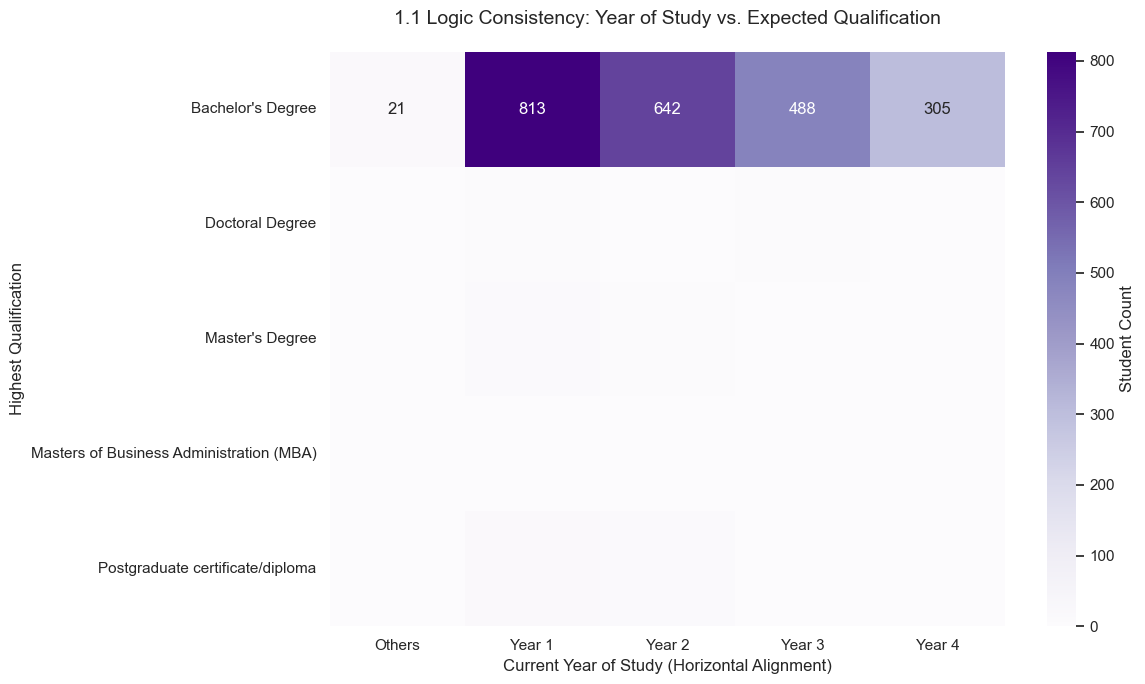

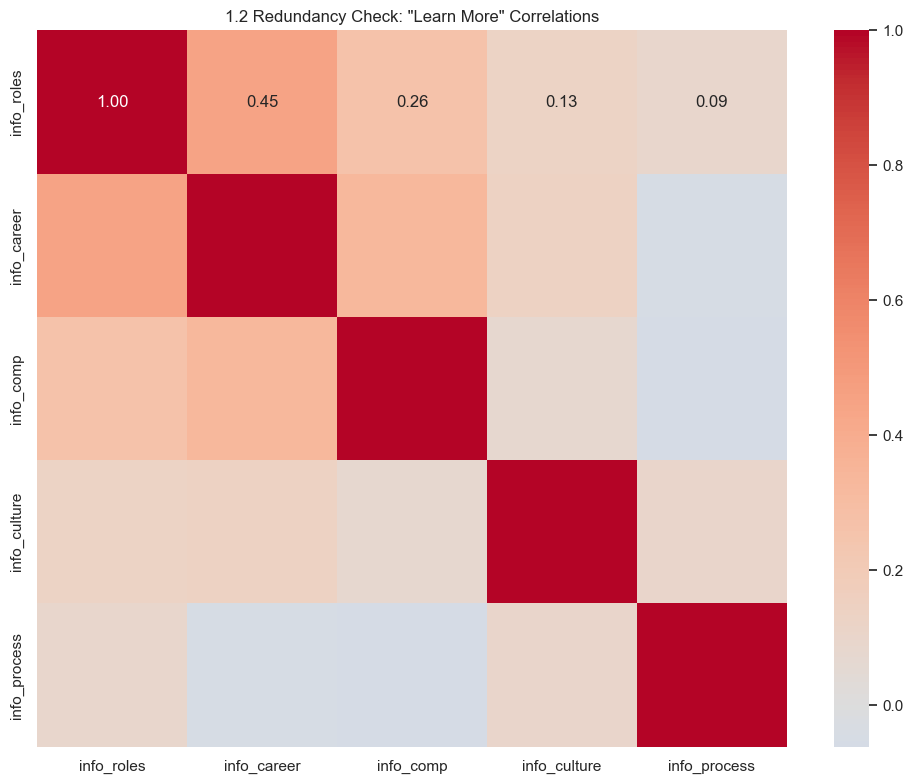

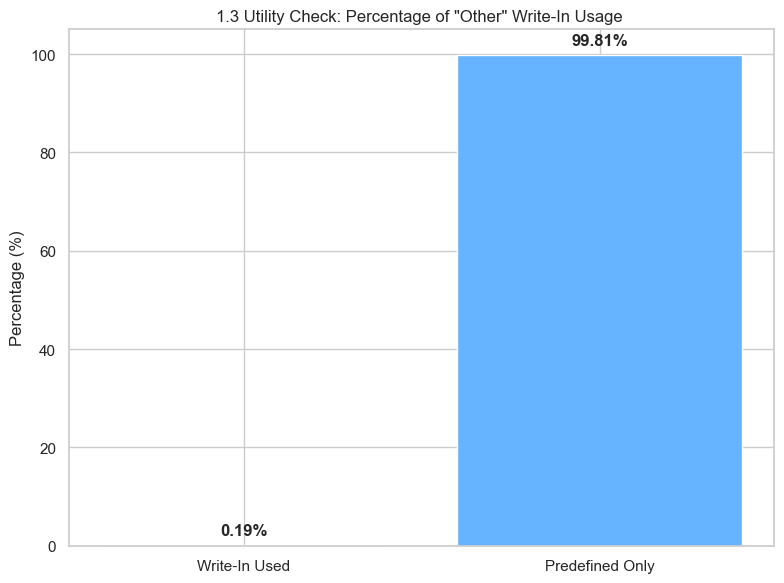

In [58]:
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd

# Set professional aesthetics for gradsingapore
sns.set_theme(style="whitegrid", palette="muted")

# 1.1 Logic Consistency: Year vs Qualification
plt.figure(figsize=(12, 7))

# 1. 'logic_df.T' transposes the data so Year 1, 2, 3, 4, and Others are on the horizontal (X) axis.
# 2. 'cmap="Purples"' ensures the highest counts are represented by the deepest purple.
sns.heatmap(logic_df.T, annot=True, fmt='d', cmap='Purples', cbar_kws={'label': 'Student Count'})

plt.title('1.1 Logic Consistency: Year of Study vs. Expected Qualification', fontsize=14, pad=20)
plt.xlabel('Current Year of Study (Horizontal Alignment)', fontsize=12)
plt.ylabel('Highest Qualification', fontsize=12)

# Ensure the year labels are perfectly horizontal
plt.xticks(rotation=0) 

plt.tight_layout()
plt.show()

# 1.2 Redundancy: Correlation Heatmap
plt.figure(figsize=(10, 8))
# We use a diverging map to see positive/negative correlations clearly
sns.heatmap(info_corr, annot=True, cmap='coolwarm', center=0, fmt='.2f')
plt.title('1.2 Redundancy Check: "Learn More" Correlations')
plt.tight_layout()
plt.show()

# 1.3 Other Field Utility: Usage Bar Chart
plt.figure(figsize=(8, 6))
usage_labels = ['Write-In Used', 'Predefined Only']
usage_values = [other_usage, 100 - other_usage]
colors = ['#ff9999','#66b3ff']
plt.bar(usage_labels, usage_values, color=colors)
plt.title('1.3 Utility Check: Percentage of "Other" Write-In Usage ')
plt.ylabel('Percentage (%)')
plt.ylim(0, 105)
# Adding percentage labels on top for clarity
for i, v in enumerate(usage_values):
    plt.text(i, v + 2, f"{v:.2f}%", ha='center', fontweight='bold')
plt.tight_layout()
plt.show()

### CATEGORY 2: Survey Status

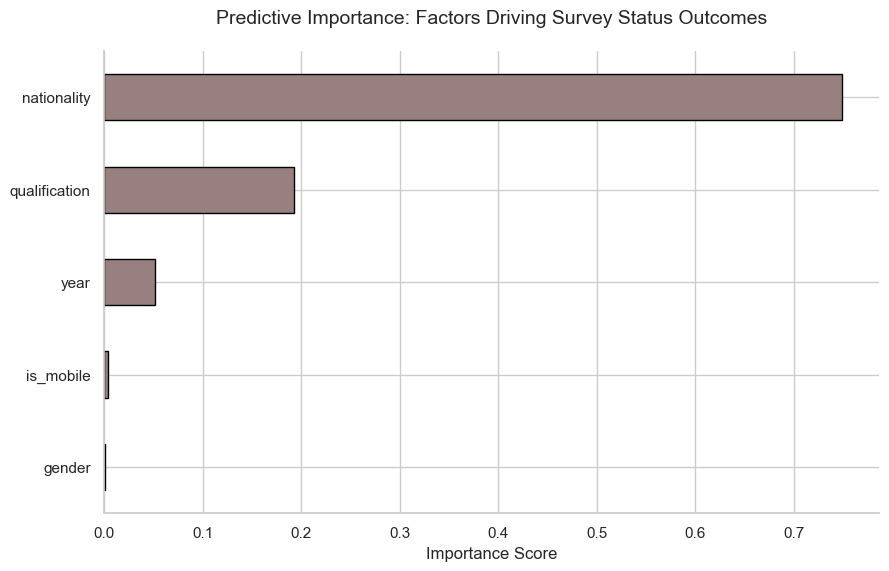

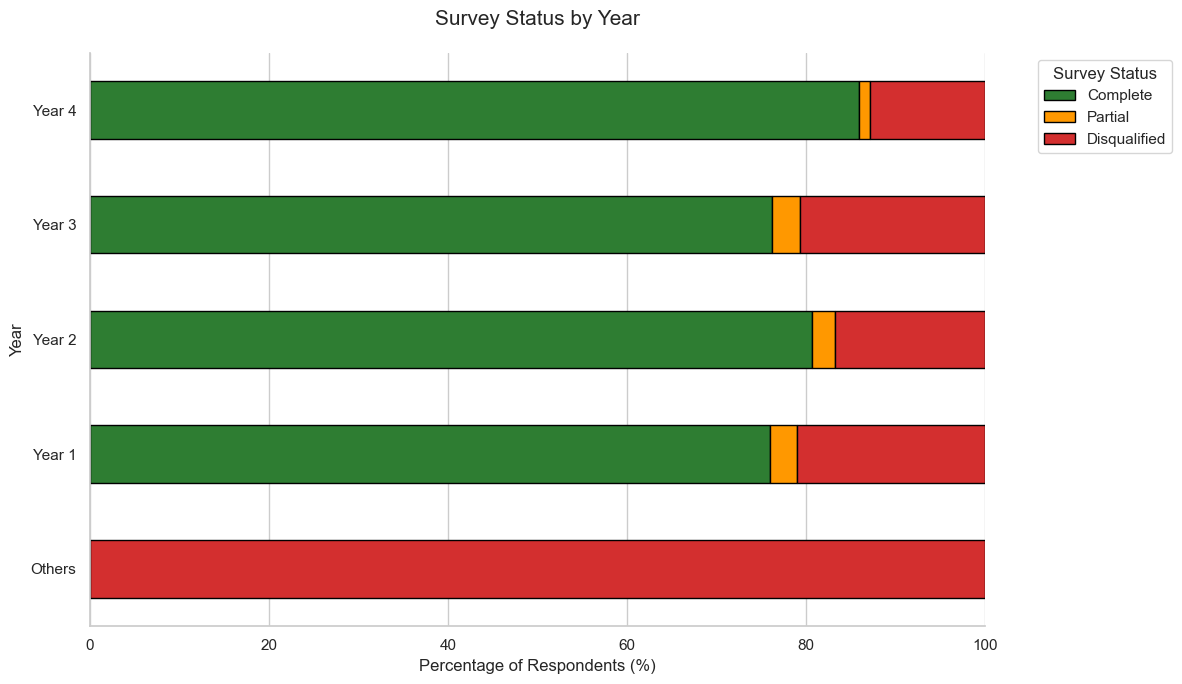

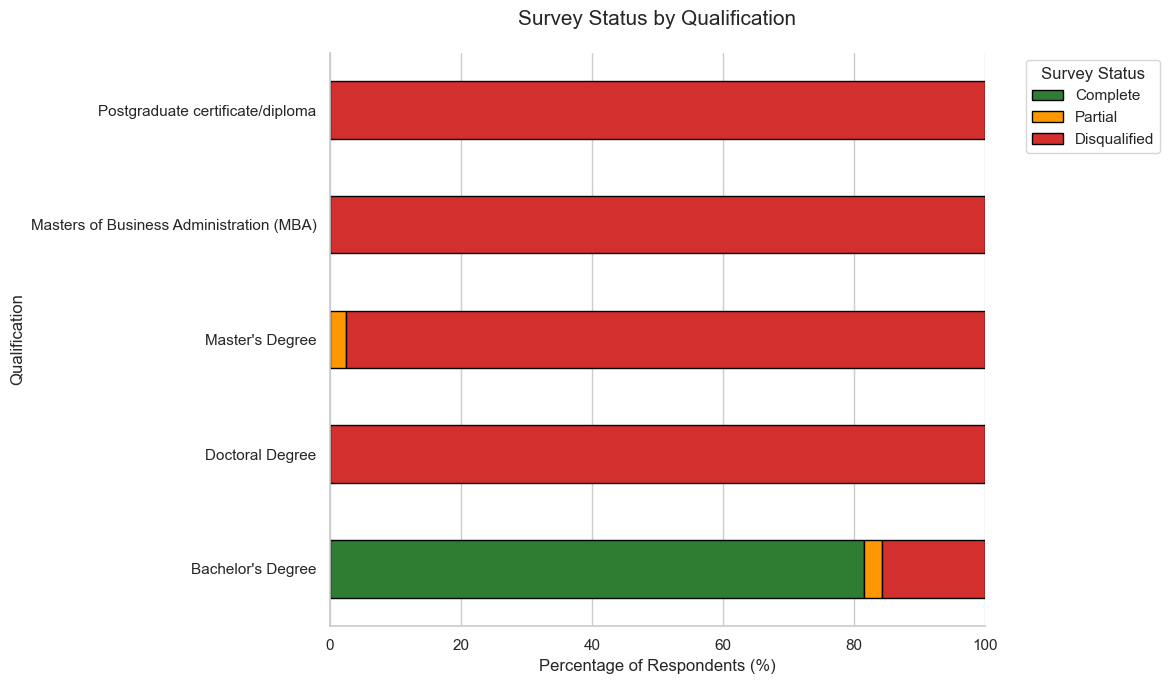

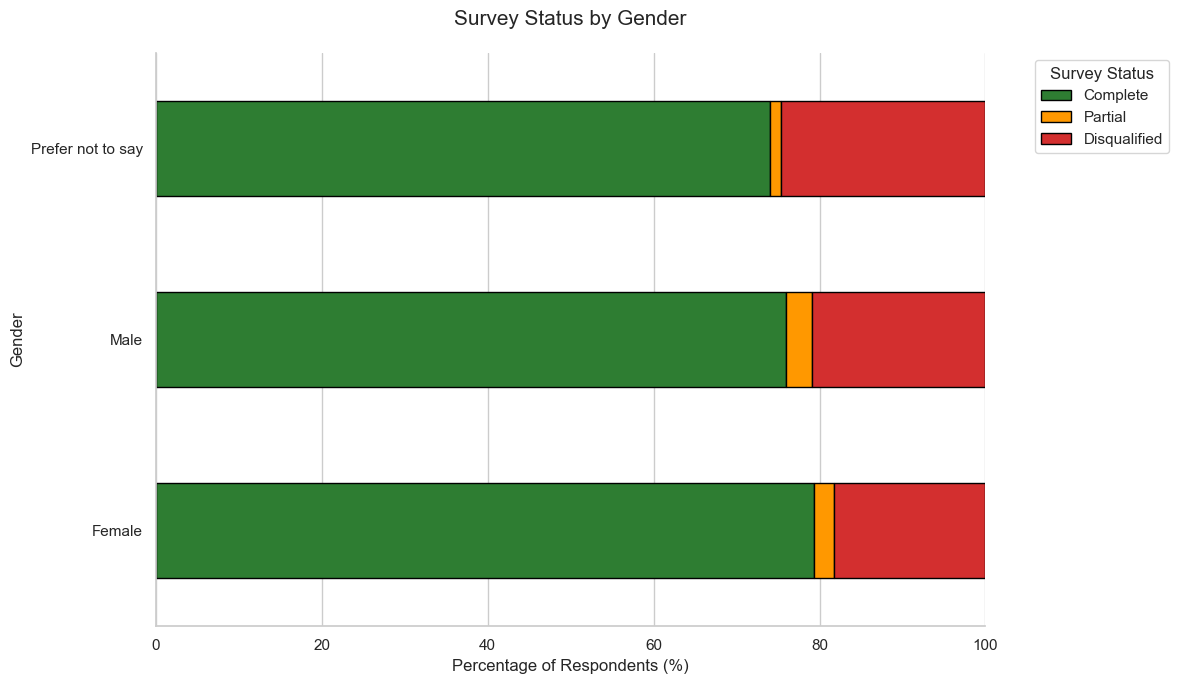

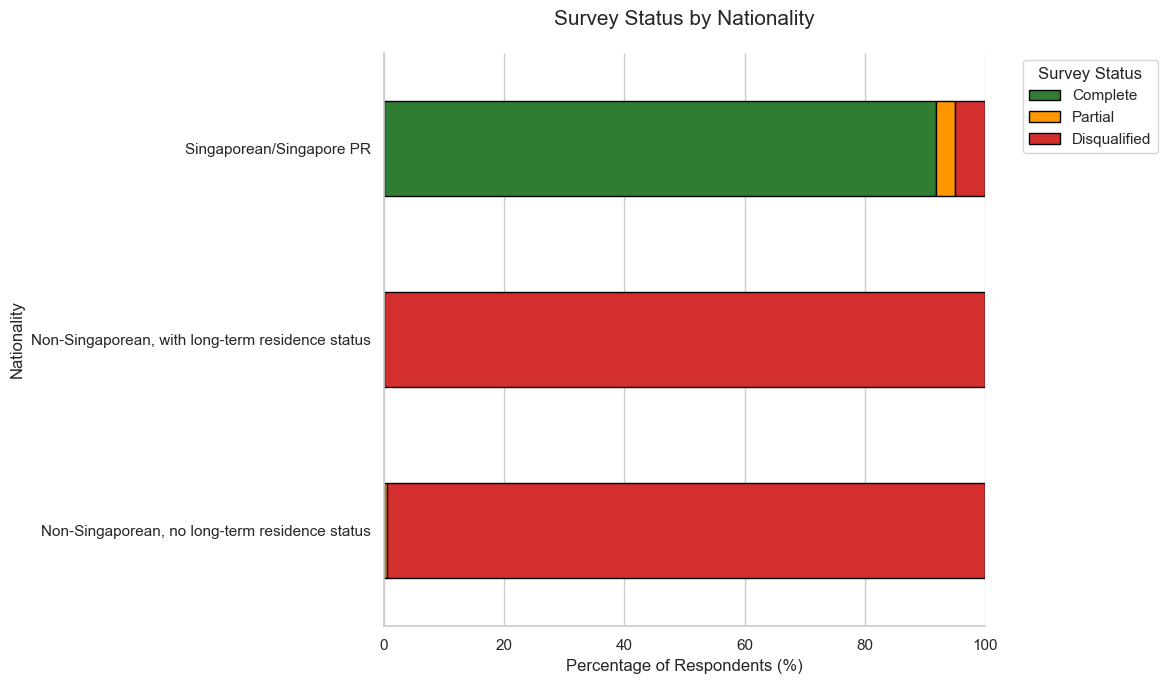

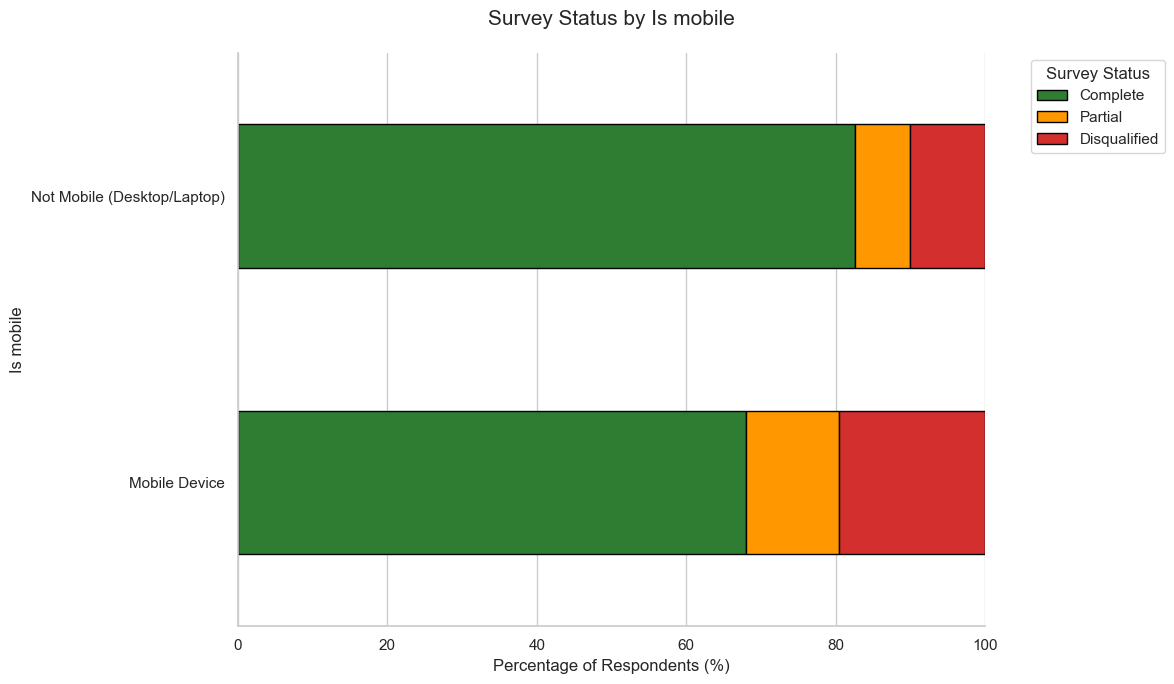

In [59]:
import pandas as pd
from sklearn.ensemble import RandomForestClassifier
from sklearn.preprocessing import LabelEncoder
import matplotlib.pyplot as plt
import seaborn as sns

# Define the specific color mapping for survey statuses
# Complete = Green, Disqualified = Red, Partial = Orange
status_colors = {
    'Complete': '#2E7D32',      # Forest Green
    'Disqualified': '#D32F2F',  # Bright Red
    'Partial': '#FF9800'        # Vibrant Orange
}

# 1. Feature Selection
analysis_vars = ['year', 'qualification', 'gender', 'nationality', 'is_mobile']

# Map label for is_mobile for cleaner horizontal axis
df['is_mobile_label'] = df['is_mobile'].map({0: 'Not Mobile (Desktop/Laptop)', 1: 'Mobile Device'})

# 2. Predictive Power (Machine Learning Importance)
# Keep binary target for importance modeling
df['is_complete'] = (df['status'] == 'Complete').astype(int)
ml_data = df[analysis_vars + ['is_complete']].dropna()
X = ml_data[analysis_vars].copy()

for col in analysis_vars:
    X[col] = LabelEncoder().fit_transform(X[col].astype(str))

rf = RandomForestClassifier(n_estimators=100, random_state=42).fit(X, ml_data['is_complete'])
importances = pd.Series(rf.feature_importances_, index=analysis_vars).sort_values(ascending=True)

# Plot 1: Importance Summary (Shows what most influences 'Status')
plt.figure(figsize=(10, 6))
importances.plot(kind='barh', color='#998080', edgecolor='black')
plt.title('Predictive Importance: Factors Driving Survey Status Outcomes', fontsize=14, pad=20)
plt.xlabel('Importance Score', fontsize=12)
sns.despine()
plt.show()

# 3. Status Insight Loop
for col in analysis_vars:
    plt.figure(figsize=(12, 7))
    
    # Handle the mobile label mapping
    col_to_plot = 'is_mobile_label' if col == 'is_mobile' else col
    
    # Create the cross-tabulation normalized to 100%
    # This shows the percentage breakdown of Status per category [cite: 19]
    status_dist = pd.crosstab(df[col_to_plot], df['status'], normalize='index') * 100
    
    # Ensure all three statuses exist in the columns to avoid color mapping errors
    available_statuses = [s for s in ['Complete', 'Partial', 'Disqualified'] if s in status_dist.columns]
    current_colors = [status_colors[s] for s in available_statuses]
    
    # Reorder columns so they appear in a logical order (Complete first)
    status_dist = status_dist[available_statuses]
    
    # Plotting Horizontal Stacked Bar
    status_dist.plot(kind='barh', stacked=True, ax=plt.gca(), color=current_colors, edgecolor='black')
    
    plt.title(f'Survey Status by {col.replace("_", " ").capitalize()}', fontsize=15, pad=20)
    plt.xlabel('Percentage of Respondents (%)', fontsize=12)
    plt.ylabel(col.replace("_", " ").capitalize(), fontsize=12)
    
    # Keep labels horizontal for readability
    plt.yticks(rotation=0)
    plt.xlim(0, 100)
    
    # Place legend outside
    plt.legend(title='Survey Status', bbox_to_anchor=(1.05, 1), loc='upper left')
    
    sns.despine()
    plt.tight_layout()
    plt.show()

/opt/anaconda3/lib/python3.11/site-packages/seaborn/_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):
/opt/anaconda3/lib/python3.11/site-packages/seaborn/_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):
/opt/anaconda3/lib/python3.11/site-packages/seaborn/_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):


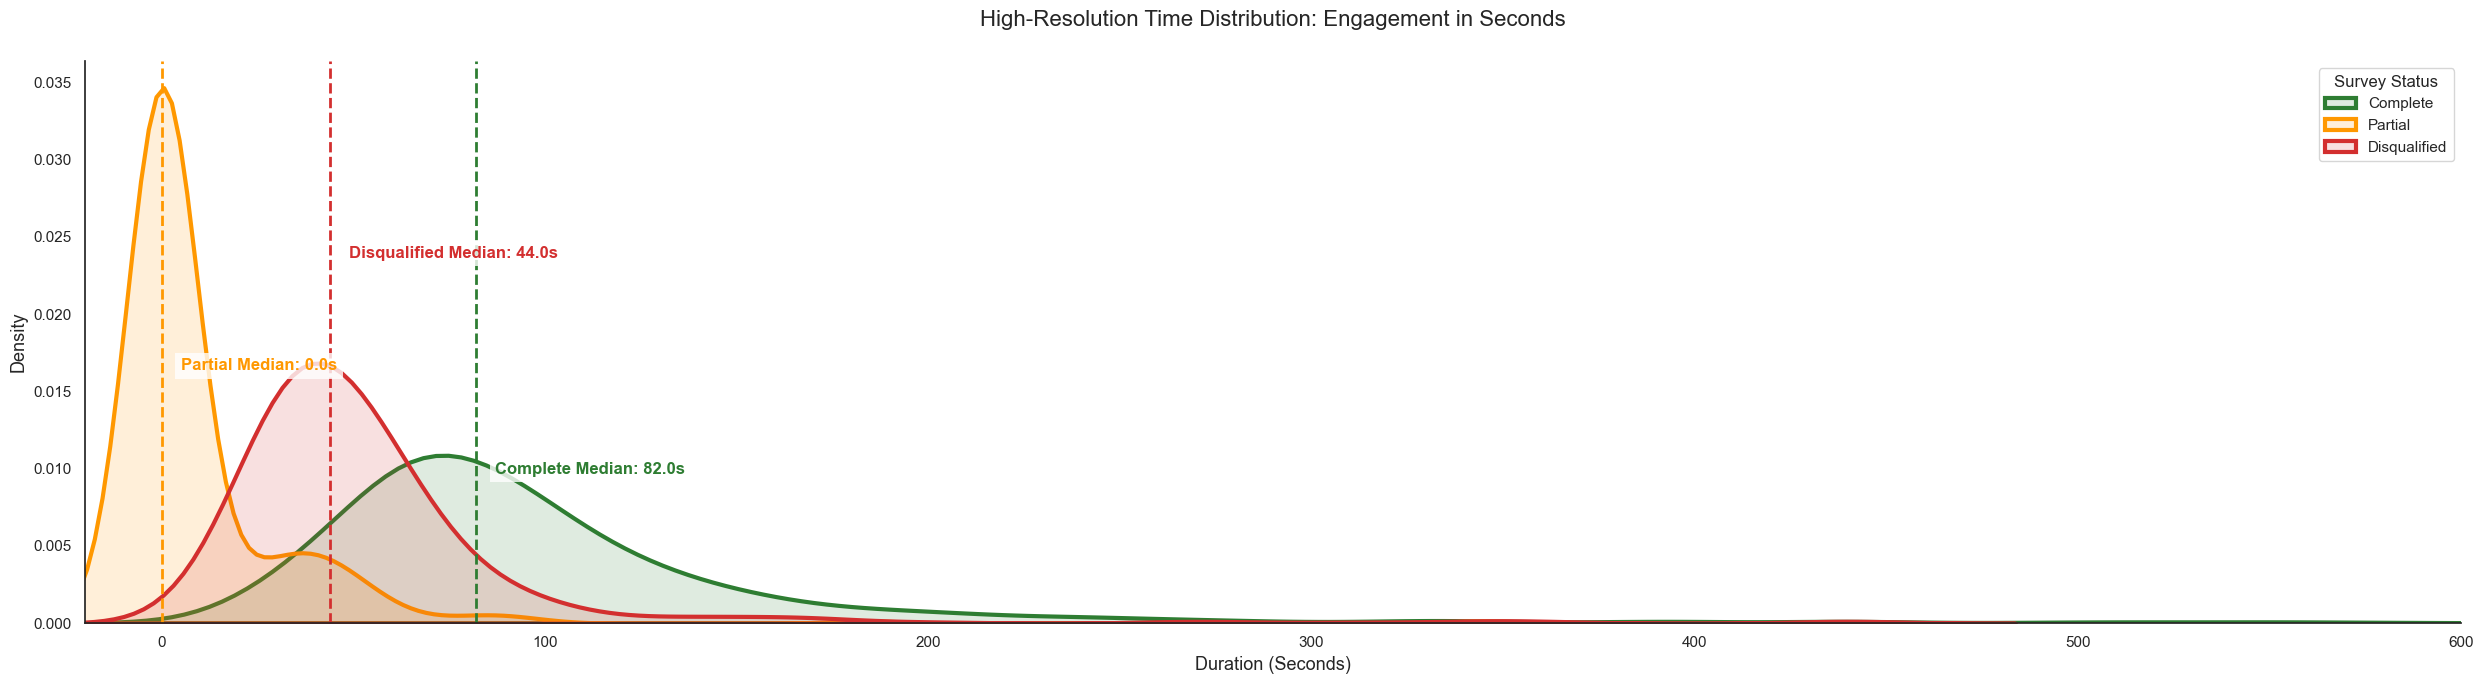

In [60]:
import matplotlib.pyplot as plt
import seaborn as sns

# 1. Calculate duration in seconds

# 2. Define Traffic Light colors
status_colors = {'Complete': '#2E7D32', 'Partial': '#FF9800', 'Disqualified': '#D32F2F'}

plt.figure(figsize=(25, 7))
sns.set_theme(style="white")

for status, color in status_colors.items():
    subset = df[(df['status'] == status) & (df['duration_sec'] <= 600)]
    
    # Line Graph (KDE)
    sns.kdeplot(subset['duration_sec'], label=status, color=color, fill=True, alpha=0.15, linewidth=3)
    
    # Median Vertical Line
    median_val = subset['duration_sec'].median()
    plt.axvline(median_val, color=color, linestyle='--', linewidth=2)
    
    # Annotate Median in Seconds
    y_pos = plt.gca().get_ylim()[1] * (0.85 if status == 'Complete' else 0.65 if status == 'Disqualified' else 0.45)
    plt.text(median_val + 5, y_pos, f'{status} Median: {median_val:.1f}s', 
             color=color, fontweight='bold', bbox=dict(facecolor='white', alpha=0.8, edgecolor='none'))

plt.title('High-Resolution Time Distribution: Engagement in Seconds', fontsize=16, pad=25)
plt.xlabel('Duration (Seconds)', fontsize=13)
plt.ylabel('Density', fontsize=13)
plt.xlim(-20, 600) # Show first 10 minutes
plt.legend(title='Survey Status', loc='upper right')

sns.despine()
plt.tight_layout()
plt.show()

/opt/anaconda3/lib/python3.11/site-packages/seaborn/categorical.py:1794: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):
/opt/anaconda3/lib/python3.11/site-packages/seaborn/categorical.py:1794: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):
/opt/anaconda3/lib/python3.11/site-packages/seaborn/categorical.py:1794: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):


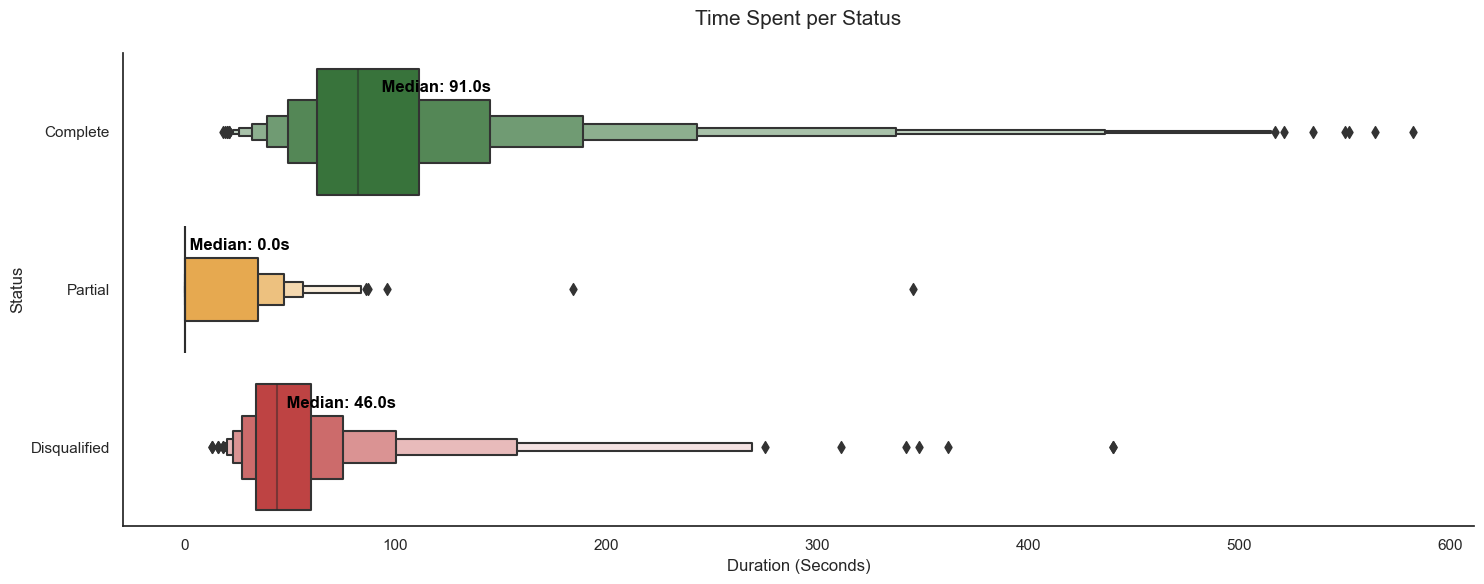

In [61]:
plt.figure(figsize=(15, 6))

# Boxen plot is great for large data and shows distribution depth
sns.boxenplot(x='duration_sec', y='status', data=df[df['duration_sec'] <= 600],
              order=['Complete', 'Partial', 'Disqualified'],
              palette=status_colors)

plt.title('Time Spent per Status', fontsize=15, pad=20)
plt.xlabel('Duration (Seconds)', fontsize=12)
plt.ylabel('Status', fontsize=12)

# Add median text labels
for i, status in enumerate(['Complete', 'Partial', 'Disqualified']):
    med = df[df['status'] == status]['duration_sec'].median()
    plt.text(med, i - 0.25, f' Median: {med:.1f}s', fontweight='bold', color='black')

sns.despine()
plt.tight_layout()
plt.show()

### CATEGORY 3: Demographics and Behaviorial Segmentation

#### Analysis 1: Interest-Based Personas

Description: Segment respondents based on their interests and hobbies to create interest-based personas. This can help in tailoring survey design strategies and inspecting quality insights.

/var/folders/59/qbzfw51d345c84sls3kvv_300000gn/T/ipykernel_74861/2472599762.py:21: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  clustering_clean['persona'] = kmeans.fit_predict(X_cluster)
/var/folders/59/qbzfw51d345c84sls3kvv_300000gn/T/ipykernel_74861/2472599762.py:63: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  clustering_clean['persona_label'] = clustering_clean['persona'].map(persona_mapping)


Cluster Centers:
   info_roles  info_career     info_comp  info_culture  info_process
0    0.327402     0.516014  1.000000e+00  9.056940e-01      0.249110
1    1.000000     0.886943  1.000000e+00  2.220446e-16      0.113057
2    0.913374     0.820669  1.110223e-15  7.689970e-01      0.490881

Persona Labels: ['Money & Career Focused', 'Roles & Exploration Focused (Type 2)', 'Roles & Exploration Focused (Type 3)']


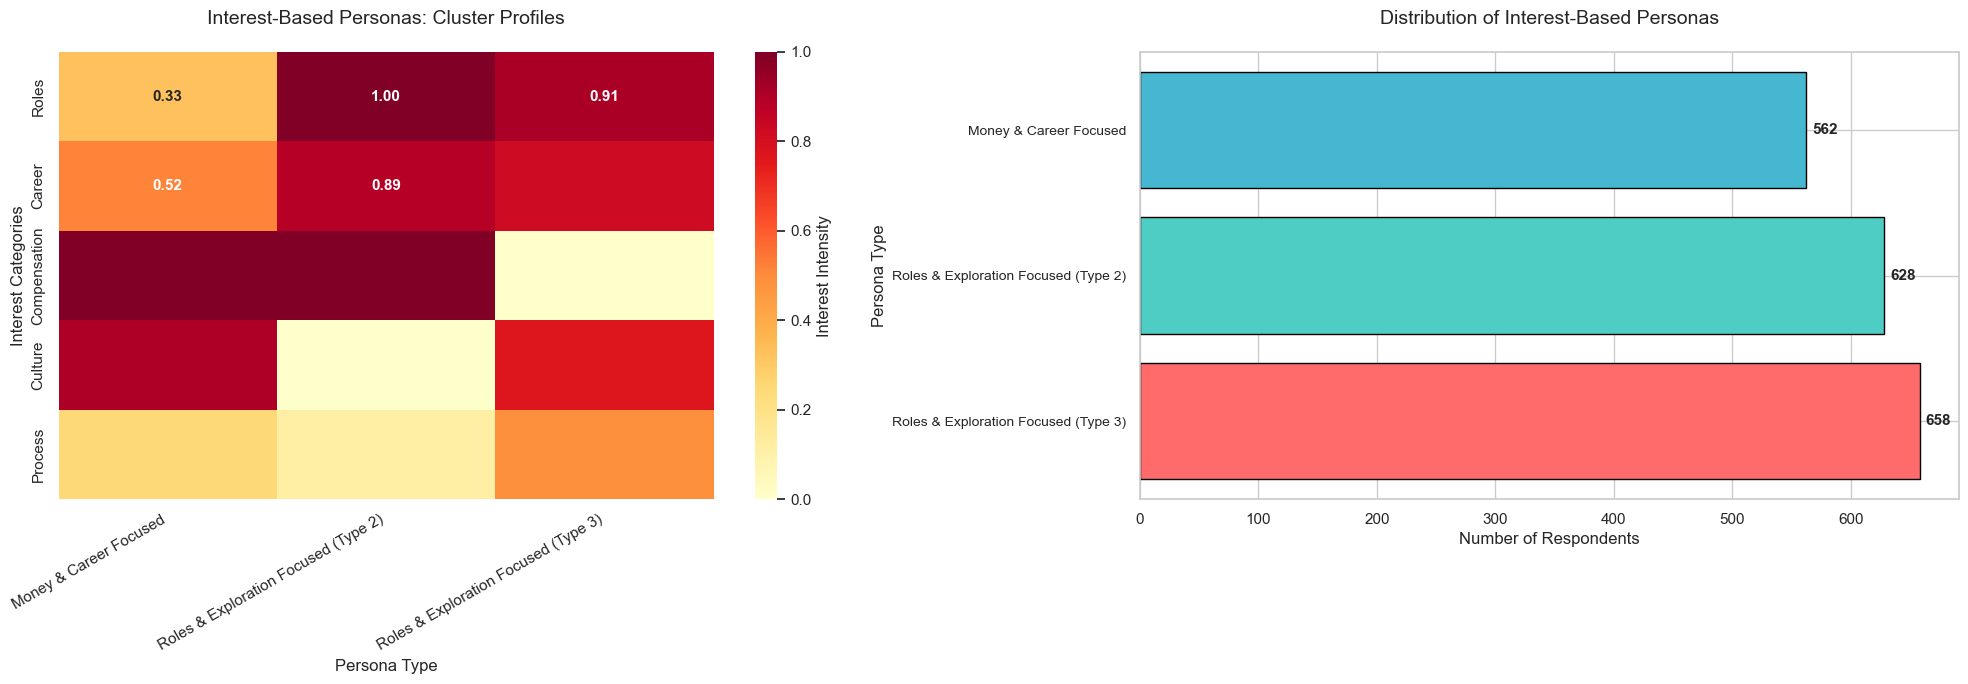

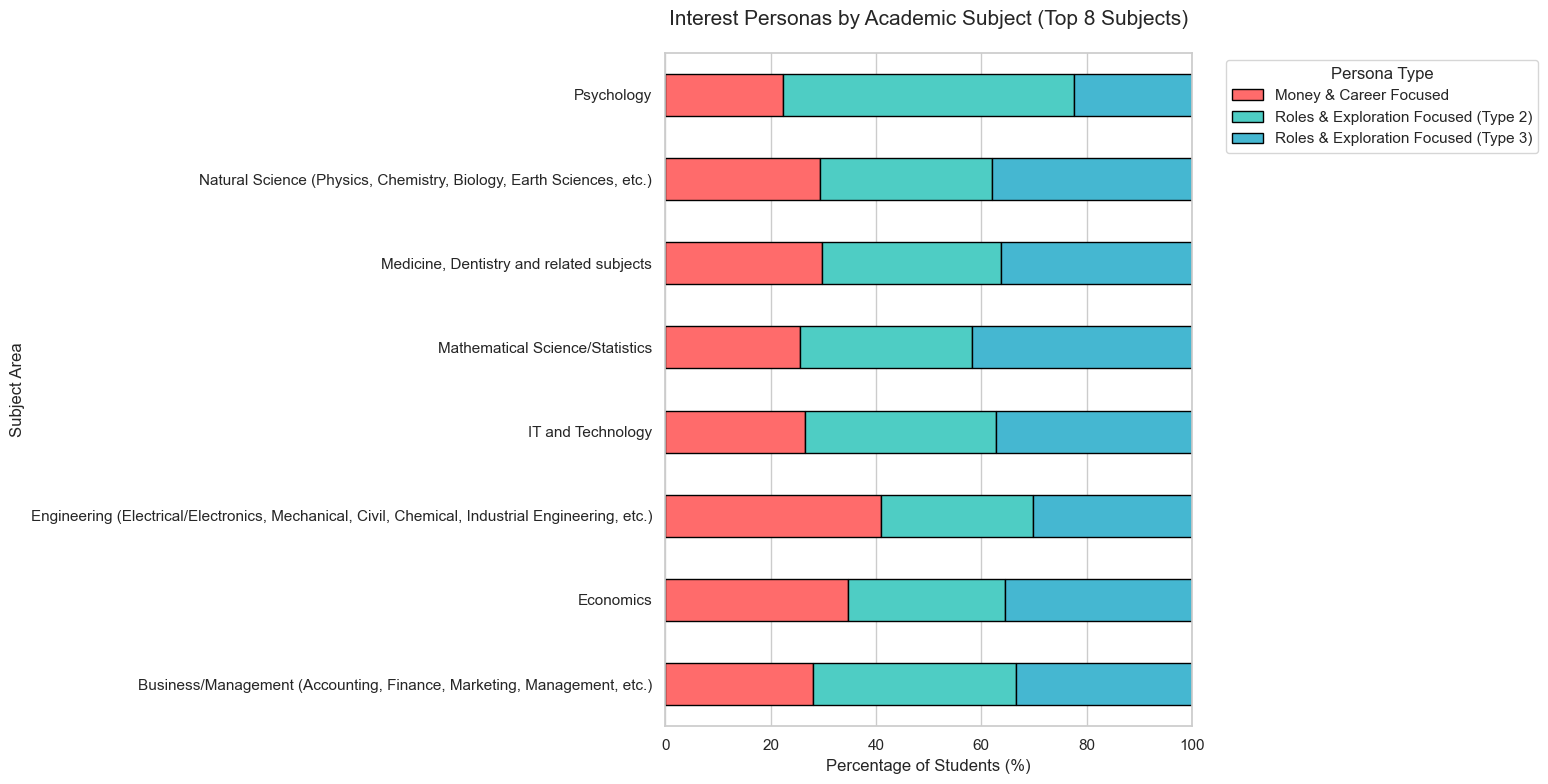


Persona Statistics by Subject:
persona_label                                       Money & Career Focused  \
subject                                                                      
Agriculture, Veterinary Science and related sub...                       9   
Architecture, Building and Planning                                     16   
Business/Management (Accounting, Finance, Marke...                      66   
Creative Arts and Design                                                10   
Economics                                                               41   
Education/Teaching                                                      12   
Engineering (Electrical/Electronics, Mechanical...                      57   
English                                                                  8   
Geography and Environmental Science                                     13   
Historical/Philosophical Science                                         2   

persona_label                  

In [62]:
import pandas as pd
import numpy as np
from sklearn.ensemble import RandomForestClassifier
from sklearn.preprocessing import LabelEncoder
import matplotlib.pyplot as plt
import plotly
import seaborn as sns

sns.set_theme(style="whitegrid", palette="Set2")


# Create binary features for "Learn More" interests
info_cols = ['info_roles', 'info_career', 'info_comp', 'info_culture', 'info_process']
clustering_data = df[info_cols + ['subject', 'attractiveness']].copy()
clustering_data[info_cols] = clustering_data[info_cols].notnull().astype(int)
clustering_clean = clustering_data.dropna(subset=['subject', 'attractiveness']) 

# Perform K-Means Clustering
X_cluster = clustering_clean[info_cols].values
kmeans = KMeans(n_clusters=3, random_state=42, n_init=10)
clustering_clean['persona'] = kmeans.fit_predict(X_cluster)

# Label personas based on cluster centers
cluster_centers = pd.DataFrame(kmeans.cluster_centers_, columns=info_cols)
persona_labels = []

for idx, row in cluster_centers.iterrows():
    # Get the dominant interest (highest value)
    top_interest = row.idxmax()
    top_value = row.max()
    
    if top_interest == 'info_comp':
        label = "Money & Career Focused"
    elif top_interest == 'info_culture':
        label = "Work-Life Balance Focused"
    elif top_interest == 'info_career':
        label = "Career Growth Focused"
    elif top_interest == 'info_roles':
        label = "Roles & Exploration Focused"
    elif top_interest == 'info_process':
        label = "Process & Application Focused"
    else:
        # For second highest
        top_two = row.nlargest(2)
        if 'info_comp' in top_two.index or 'info_career' in top_two.index:
            label = "Money & Career Focused"
        elif 'info_culture' in top_two.index:
            label = "Work-Life Balance Focused"
        else:
            label = f"Cluster {idx}"
    
    persona_labels.append(label)

unique_labels = []
for i, label in enumerate(persona_labels):
    if persona_labels.count(label) > 1:
        unique_labels.append(f"{label} (Type {i+1})")
    else:
        unique_labels.append(label)
persona_labels = unique_labels

persona_mapping = {i: persona_labels[i] for i in range(3)}
clustering_clean['persona_label'] = clustering_clean['persona'].map(persona_mapping)

print("Cluster Centers:")
print(cluster_centers)
print("\nPersona Labels:", persona_labels)

### Visualization 1: Cluster Centers Heatmap
fig, axes = plt.subplots(1, 2, figsize=(20, 7))

# Heatmap of cluster characteristics
sns.heatmap(cluster_centers.T, annot=True, fmt='.2f', cmap='YlOrRd', 
            xticklabels=[persona_labels[i] for i in range(3)],
            yticklabels=['Roles', 'Career', 'Compensation', 'Culture', 'Process'],
            ax=axes[0], cbar_kws={'label': 'Interest Intensity'},
            annot_kws={'size': 11, 'weight': 'bold'})  
axes[0].set_title('Interest-Based Personas: Cluster Profiles', fontsize=14, pad=20)
axes[0].set_xlabel('Persona Type', fontsize=12)
axes[0].set_ylabel('Interest Categories', fontsize=12)
axes[0].set_xticklabels(axes[0].get_xticklabels(), rotation=30, ha='right')

persona_counts = clustering_clean['persona_label'].value_counts()
colors_persona = ['#FF6B6B', '#4ECDC4', '#45B7D1']
axes[1].barh(persona_counts.index, persona_counts.values, color=colors_persona, edgecolor='black')
axes[1].set_title('Distribution of Interest-Based Personas', fontsize=14, pad=20)
axes[1].set_xlabel('Number of Respondents', fontsize=12)
axes[1].set_ylabel('Persona Type', fontsize=12)
axes[1].tick_params(axis='y', labelsize=10)
plt.setp(axes[1].get_yticklabels(), rotation=0, ha='right')

for i, v in enumerate(persona_counts.values):
    axes[1].text(v + 5, i, str(v), va='center', fontweight='bold', fontsize=11)

plt.tight_layout()
plt.show()

# Visualization 2: Personas by Subject (Are IT students more $ focused?)
plt.figure(figsize=(16, 8))
subject_persona = pd.crosstab(clustering_clean['subject'], 
                               clustering_clean['persona_label'], 
                               normalize='index') * 100

# Get top subjects by count
top_subjects = clustering_clean['subject'].value_counts().head(8).index
subject_persona_top = subject_persona.loc[subject_persona.index.isin(top_subjects)]

subject_persona_top.plot(kind='barh', stacked=True, 
                         color=colors_persona, 
                         edgecolor='black', ax=plt.gca())
plt.title('Interest Personas by Academic Subject (Top 8 Subjects)', fontsize=15, pad=20)
plt.xlabel('Percentage of Students (%)', fontsize=12)
plt.ylabel('Subject Area', fontsize=12)
plt.xlim(0, 100)
plt.legend(title='Persona Type', bbox_to_anchor=(1.05, 1), loc='upper left')
plt.tight_layout()
plt.show()

# Statistical summary
print("\nPersona Statistics by Subject:")
persona_subject_stats = clustering_clean.groupby(['subject', 'persona_label']).size().unstack(fill_value=0)
print(persona_subject_stats.head(10))


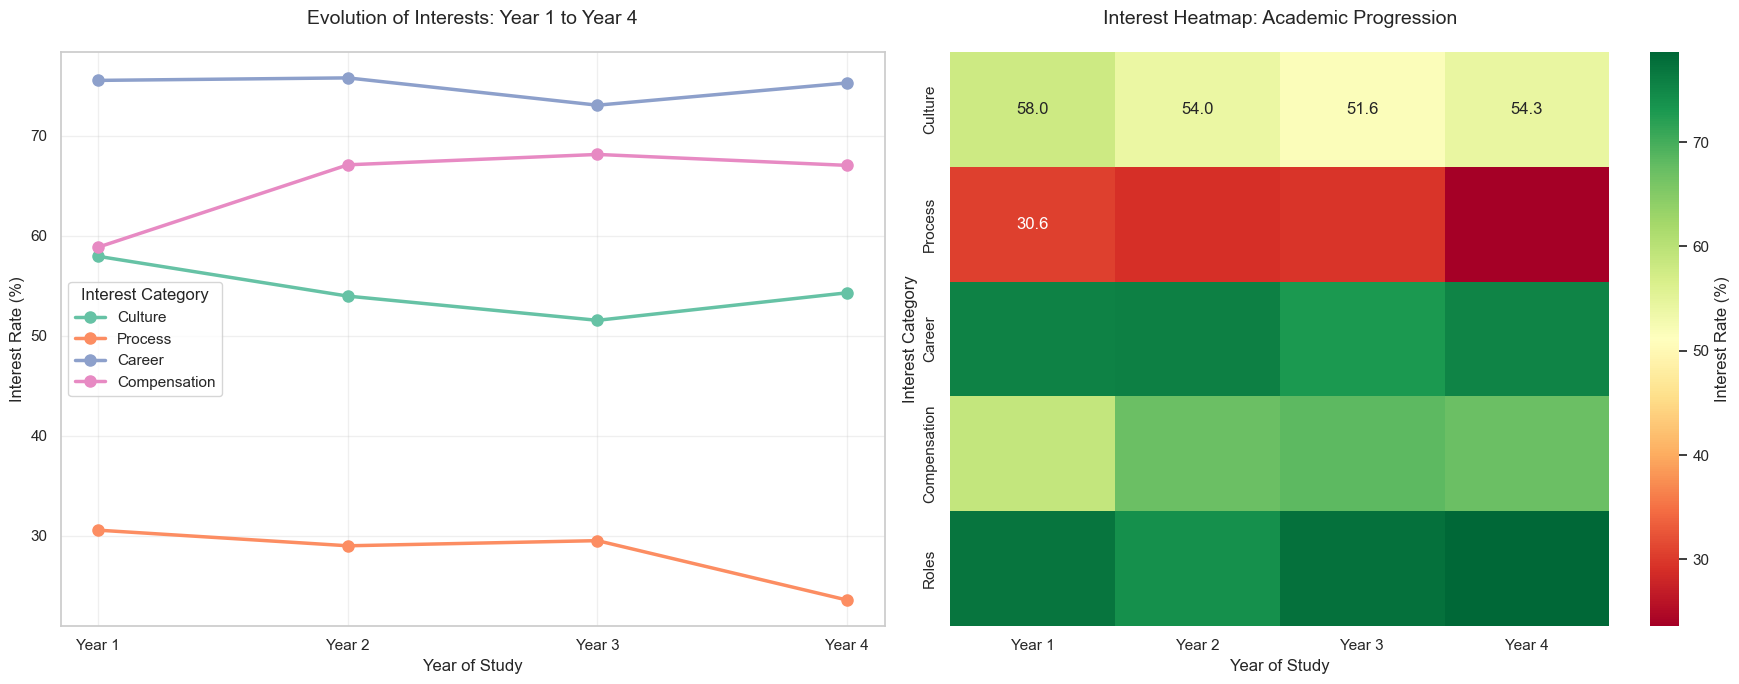

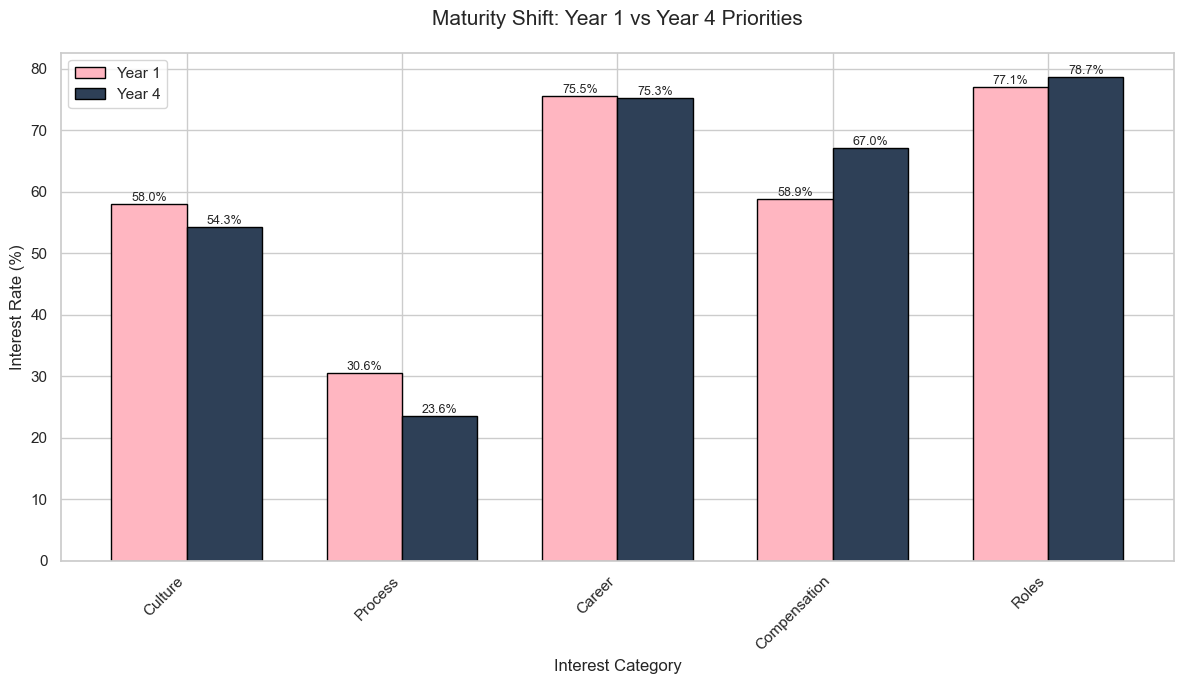


Year 1 to Year 4 Change (percentage points):
Compensation    8.172697
Roles           1.587465
Career         -0.254269
Culture        -3.643954
Process        -6.985534
dtype: float64


In [63]:
maturity_data = df[df['status'] == 'Complete'].copy()
maturity_data = maturity_data[maturity_data['year'].isin(['Year 1', 'Year 2', 'Year 3', 'Year 4'])]

# Calculate interest rates by year
year_interests = {}
for year in ['Year 1', 'Year 2', 'Year 3', 'Year 4']:
    year_df = maturity_data[maturity_data['year'] == year]
    year_interests[year] = {
        'Culture': (year_df['info_culture'].notnull().sum() / len(year_df)) * 100,
        'Process': (year_df['info_process'].notnull().sum() / len(year_df)) * 100,
        'Career': (year_df['info_career'].notnull().sum() / len(year_df)) * 100,
        'Compensation': (year_df['info_comp'].notnull().sum() / len(year_df)) * 100,
        'Roles': (year_df['info_roles'].notnull().sum() / len(year_df)) * 100,
    }

year_interest_df = pd.DataFrame(year_interests).T

# Visualization 2.1: Line plot showing evolution
fig, axes = plt.subplots(1, 2, figsize=(18, 7))

# Line plot for key interests
key_categories = ['Culture', 'Process', 'Career', 'Compensation']
for category in key_categories:
    axes[0].plot(year_interest_df.index, year_interest_df[category], 
                 marker='o', linewidth=2.5, markersize=8, label=category)

axes[0].set_title('Evolution of Interests: Year 1 to Year 4', fontsize=14, pad=20)
axes[0].set_xlabel('Year of Study', fontsize=12)
axes[0].set_ylabel('Interest Rate (%)', fontsize=12)
axes[0].legend(title='Interest Category', loc='best')
axes[0].grid(True, alpha=0.3)

# Heatmap showing all interests by year
sns.heatmap(year_interest_df.T, annot=True, fmt='.1f', cmap='RdYlGn', 
            ax=axes[1], cbar_kws={'label': 'Interest Rate (%)'})
axes[1].set_title('Interest Heatmap: Academic Progression', fontsize=14, pad=20)
axes[1].set_xlabel('Year of Study', fontsize=12)
axes[1].set_ylabel('Interest Category', fontsize=12)

plt.tight_layout()
plt.show()

# Visualization 2.2: Year 1 vs Year 4 Direct Comparison
plt.figure(figsize=(12, 7))
year_comparison = year_interest_df.loc[['Year 1', 'Year 4']].T
x = np.arange(len(year_comparison.index))
width = 0.35

bars1 = plt.bar(x - width/2, year_comparison['Year 1'], width, 
                label='Year 1', color='#FFB6C1', edgecolor='black')
bars2 = plt.bar(x + width/2, year_comparison['Year 4'], width, 
                label='Year 4', color='#2E4057', edgecolor='black')

plt.xlabel('Interest Category', fontsize=12)
plt.ylabel('Interest Rate (%)', fontsize=12)
plt.title('Maturity Shift: Year 1 vs Year 4 Priorities', fontsize=15, pad=20)
plt.xticks(x, year_comparison.index, rotation=45, ha='right')
plt.legend()

# Add value labels on bars
for bars in [bars1, bars2]:
    for bar in bars:
        height = bar.get_height()
        plt.text(bar.get_x() + bar.get_width()/2., height,
                f'{height:.1f}%', ha='center', va='bottom', fontsize=9)

plt.tight_layout()
plt.show()

# Calculate percentage change
print("\nYear 1 to Year 4 Change (percentage points):")
change = year_interest_df.loc['Year 4'] - year_interest_df.loc['Year 1']
print(change.sort_values(ascending=False))

<Figure size 1400x700 with 0 Axes>

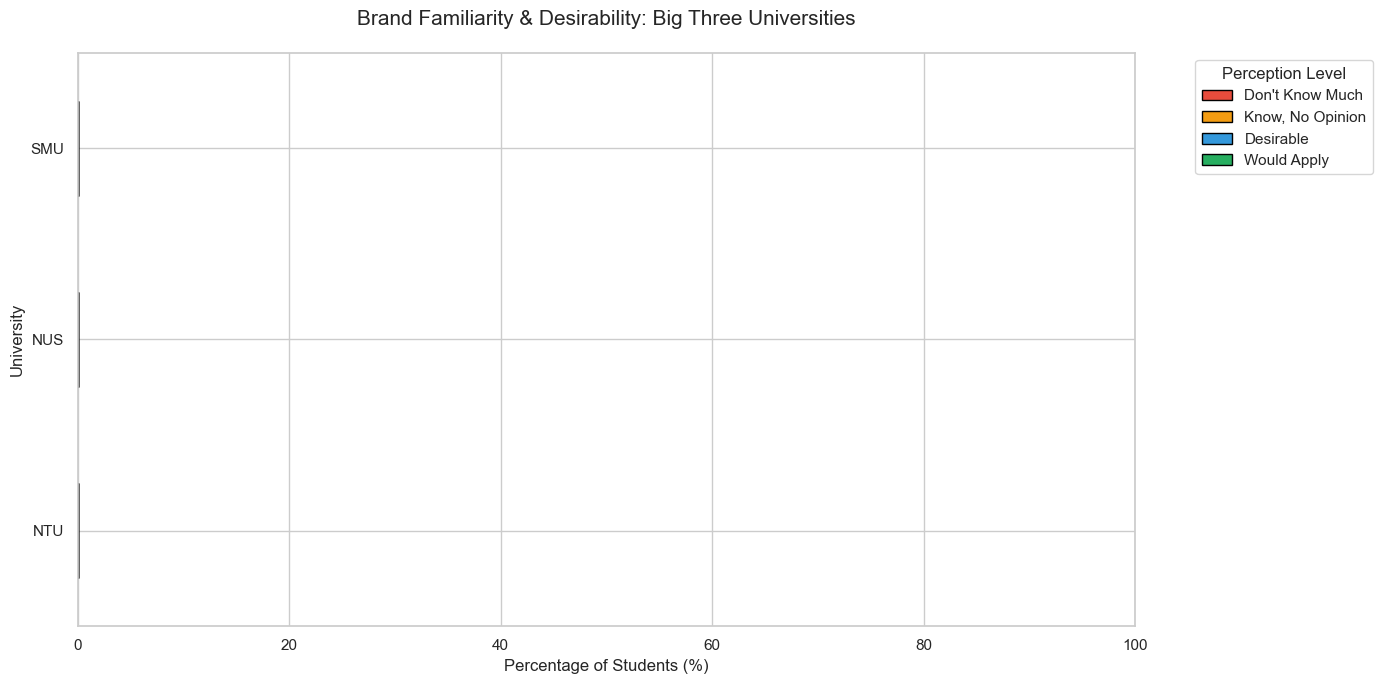

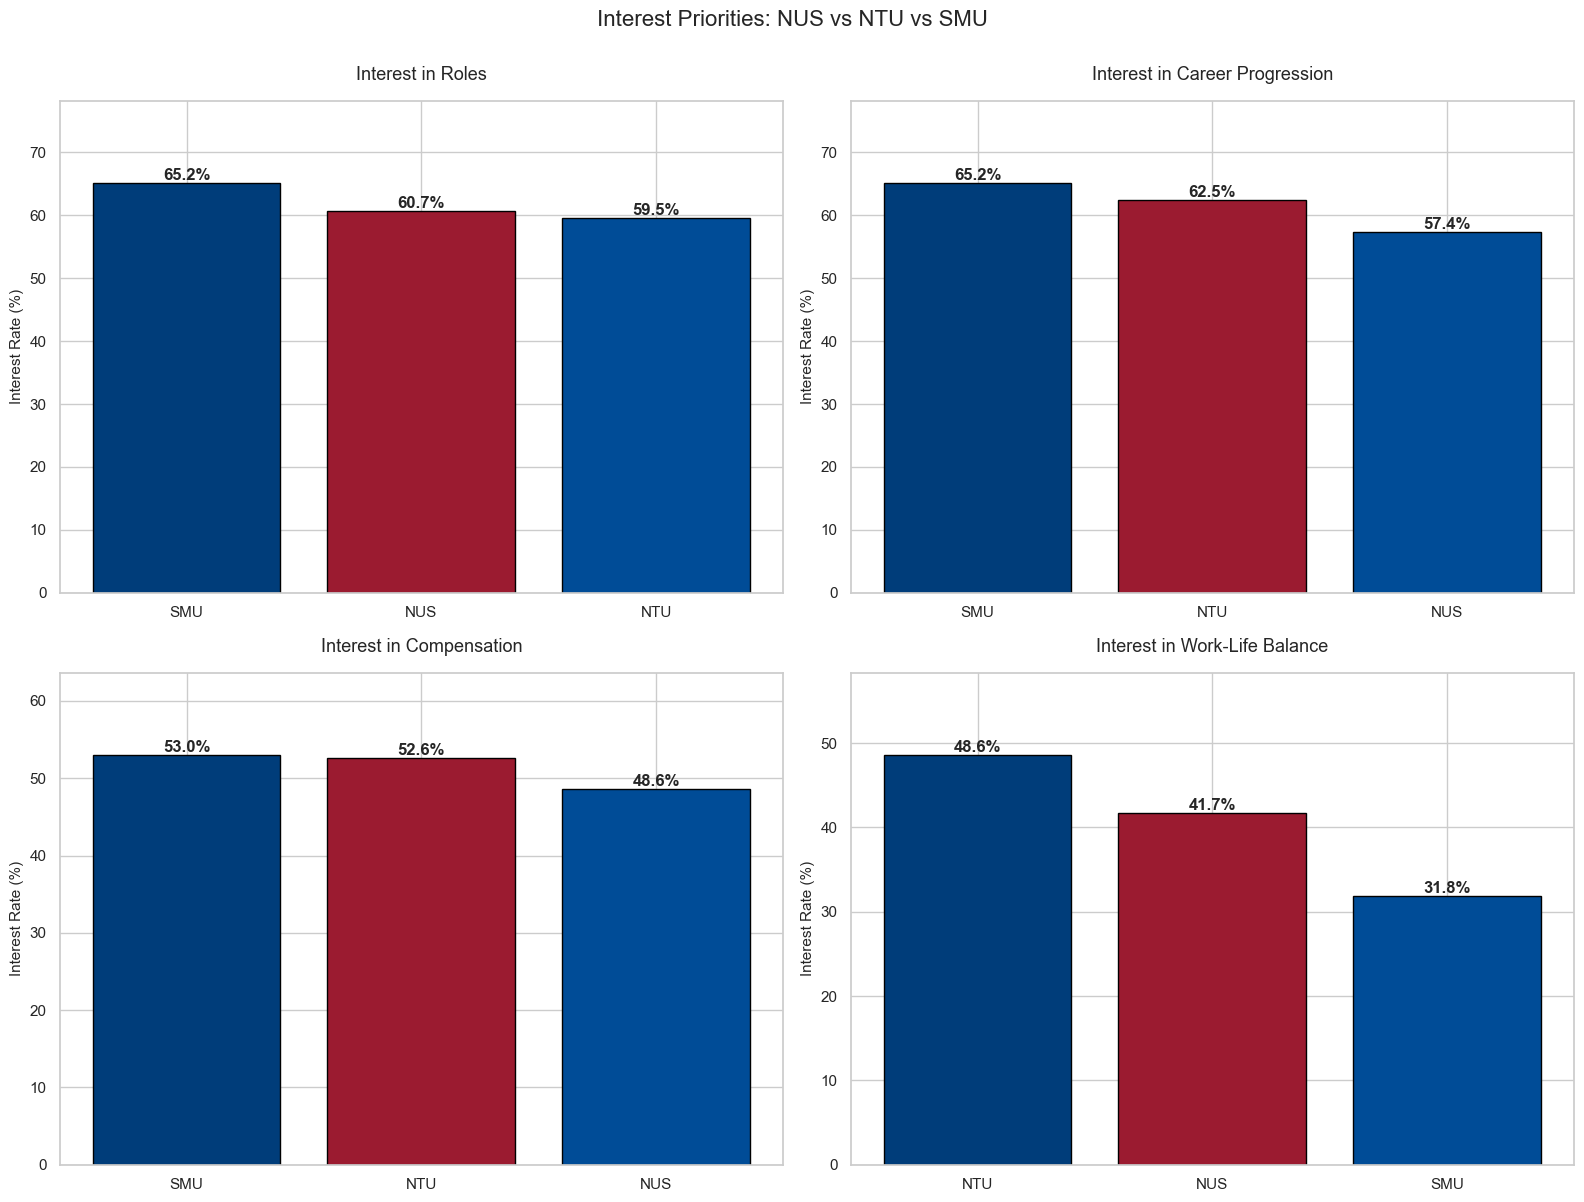

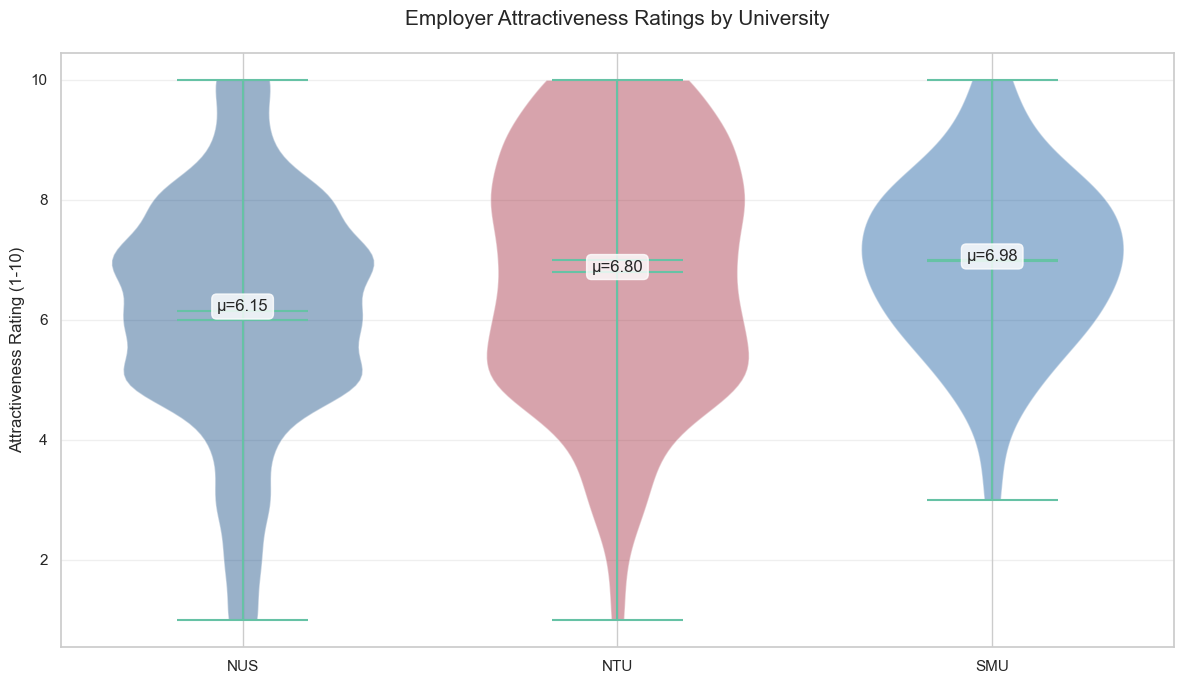


University Statistics:
            count      mean       std  min  25%  50%  75%   max
uni_short                                                      
NTU         424.0  6.804245  2.043702  1.0  5.0  7.0  8.0  10.0
NUS        1199.0  6.145955  1.960686  1.0  5.0  6.0  7.0  10.0
SMU          51.0  6.980392  1.435133  3.0  6.0  7.0  8.0  10.0


In [64]:
# Filter for Big Three universities
big_three = ['National University of Singapore (NUS)', 
             'Nanyang Technological University (NTU)', 
             'Singapore Management University (SMU)']

uni_data = df[df['university'].isin(big_three)].copy()

uni_data['uni_short'] = uni_data['university'].map({
    'National University of Singapore (NUS)': 'NUS',
    'Nanyang Technological University (NTU)': 'NTU',
    'Singapore Management University (SMU)': 'SMU'
})

# Visualization 3.1: Brand Familiarity (Perception)
plt.figure(figsize=(14, 7))

perception_order = [
    'I dont know much about this organisation.',
    'I know about this organisation but have no opinion on it as an employer.',
    'I think this organisation would be a desirable place to work.',
    'I would apply for a position at this organisation.'
]

perception_uni = pd.crosstab(uni_data['uni_short'], 
                             uni_data['perception'], 
                             normalize='index') * 100

for perc in perception_order:
    if perc not in perception_uni.columns:
        perception_uni[perc] = 0

perception_uni = perception_uni[perception_order]

colors_perception = ['#E74C3C', '#F39C12', '#3498DB', '#27AE60']
perception_uni.plot(kind='barh', stacked=True, color=colors_perception, 
                    edgecolor='black', figsize=(14, 7))

plt.title('Brand Familiarity & Desirability: Big Three Universities', fontsize=15, pad=20)
plt.xlabel('Percentage of Students (%)', fontsize=12)
plt.ylabel('University', fontsize=12)
plt.xlim(0, 100)
plt.legend(title='Perception Level', bbox_to_anchor=(1.05, 1), loc='upper left', 
           labels=['Don\'t Know Much', 'Know, No Opinion', 'Desirable', 'Would Apply'])
plt.tight_layout()
plt.show()

# Visualization 3.2: Interest Priorities by University
fig, axes = plt.subplots(2, 2, figsize=(16, 12))
axes = axes.flatten()

interest_categories = {
    'Roles': 'info_roles',
    'Career Progression': 'info_career',
    'Compensation': 'info_comp',
    'Work-Life Balance': 'info_culture'
}

for idx, (name, col) in enumerate(interest_categories.items()):
    uni_interest = uni_data.groupby('uni_short')[col].apply(
        lambda x: (x.notnull().sum() / len(x)) * 100
    ).sort_values(ascending=False)
    
    bars = axes[idx].bar(uni_interest.index, uni_interest.values, 
                         color=['#003D7A', '#9B1B30', '#004C97'], edgecolor='black')
    axes[idx].set_title(f'Interest in {name}', fontsize=13, pad=15)
    axes[idx].set_ylabel('Interest Rate (%)', fontsize=11)
    axes[idx].set_ylim(0, max(uni_interest.values) * 1.2)
    
    for bar in bars:
        height = bar.get_height()
        axes[idx].text(bar.get_x() + bar.get_width()/2., height,
                      f'{height:.1f}%', ha='center', va='bottom', fontweight='bold')

plt.suptitle('Interest Priorities: NUS vs NTU vs SMU', fontsize=16, y=1.00)
plt.tight_layout()
plt.show()

# Visualization 3.3: Attractiveness Rating by University
plt.figure(figsize=(12, 7))
uni_data_clean = uni_data.dropna(subset=['attractiveness'])

parts = plt.violinplot([uni_data_clean[uni_data_clean['uni_short'] == uni]['attractiveness'].values 
                        for uni in ['NUS', 'NTU', 'SMU']], 
                       positions=[1, 2, 3], widths=0.7, 
                       showmeans=True, showmedians=True)

colors_uni = ['#003D7A', '#9B1B30', '#004C97']
for patch, color in zip(parts['bodies'], colors_uni):
    patch.set_facecolor(color)
    patch.set_alpha(0.4)

plt.xticks([1, 2, 3], ['NUS', 'NTU', 'SMU'])
plt.ylabel('Attractiveness Rating (1-10)', fontsize=12)
plt.title('Employer Attractiveness Ratings by University', fontsize=15, pad=20)
plt.grid(axis='y', alpha=0.3)

for i, uni in enumerate(['NUS', 'NTU', 'SMU']):
    mean_val = uni_data_clean[uni_data_clean['uni_short'] == uni]['attractiveness'].mean()
    plt.text(i+1, mean_val, f'μ={mean_val:.2f}', ha='center', 
             bbox=dict(boxstyle='round', facecolor='white', alpha=0.8))

plt.tight_layout()
plt.show()

print("\nUniversity Statistics:")
print(uni_data.groupby('uni_short')['attractiveness'].describe())

In [65]:
# Create Singaporean vs Non-Singaporean segments
nationality_data = df[df['nationality'].notna()].copy()
nationality_data['is_singaporean'] = nationality_data['nationality'].str.contains(
    'Singapore', case=False, na=False
).map({True: 'Singaporean', False: 'Non-Singaporean'})

# Check the distribution first
print("Nationality Distribution:")
print(nationality_data['is_singaporean'].value_counts())
print(f"\nTotal records: {len(nationality_data)}")

# Define interest categories mapping
interest_categories = {
    'Roles': 'info_roles',
    'Career Progression': 'info_career',
    'Compensation': 'info_comp',
    'Work-Life Balance': 'info_culture'
}

# Check if we have both groups
available_groups = nationality_data['is_singaporean'].unique()
print(f"\nAvailable nationality groups: {available_groups}")

if len(available_groups) < 2:
    print("This analysis requires both Singaporean and Non-Singaporean respondents.")
    print("Skipping nationality comparison analysis.")
else:
    # Visualization 4.1: Interest Priorities by Nationality
    plt.figure(figsize=(14, 8))
    
    interest_by_nationality = {}
    for interest_name, col in interest_categories.items():
        interest_by_nationality[interest_name] = nationality_data.groupby('is_singaporean')[col].apply(
            lambda x: (x.notnull().sum() / len(x)) * 100
        )
    
    nationality_interest_df = pd.DataFrame(interest_by_nationality)
    
    print("\nInterest rates by nationality:")
    print(nationality_interest_df)
    
    x = np.arange(len(nationality_interest_df.columns))
    width = 0.35
    
    # Check which groups exist and plot accordingly
    if 'Singaporean' in nationality_interest_df.index:
        bars1 = plt.bar(x - width/2, nationality_interest_df.loc['Singaporean'], 
                        width, label='Singaporean', color='#C41E3A', edgecolor='black')
        
        # Add value labels
        for bar in bars1:
            height = bar.get_height()
            plt.text(bar.get_x() + bar.get_width()/2., height,
                    f'{height:.1f}%', ha='center', va='bottom', fontsize=9)
    
    if 'Non-Singaporean' in nationality_interest_df.index:
        bars2 = plt.bar(x + width/2, nationality_interest_df.loc['Non-Singaporean'], 
                        width, label='Non-Singaporean', color='#00247D', edgecolor='black')
        
        # Add value labels
        for bar in bars2:
            height = bar.get_height()
            plt.text(bar.get_x() + bar.get_width()/2., height,
                    f'{height:.1f}%', ha='center', va='bottom', fontsize=9)
    
    plt.xlabel('Interest Category', fontsize=12)
    plt.ylabel('Interest Rate (%)', fontsize=12)
    plt.title('Interest Priorities: Singaporean vs Non-Singaporean Students', fontsize=15, pad=20)
    plt.xticks(x, nationality_interest_df.columns, rotation=30, ha='right')
    plt.legend()
    plt.tight_layout()
    plt.show()
    
    # Visualization 4.2: Motivation Factors by Nationality
    plt.figure(figsize=(16, 10))
    
    motivation_data = nationality_data[nationality_data['motivation'].notna()]
    
    if len(motivation_data) > 0 and len(motivation_data['is_singaporean'].unique()) > 1:
        motivation_by_nat = pd.crosstab(motivation_data['is_singaporean'], 
                                         motivation_data['motivation'], 
                                         normalize='index') * 100
        
        # Get top motivations
        top_motivations = motivation_data['motivation'].value_counts().head(8).index
        motivation_by_nat_top = motivation_by_nat[[col for col in top_motivations if col in motivation_by_nat.columns]]
        
        motivation_by_nat_top.T.plot(kind='barh', color=['#C41E3A', '#00247D'], 
                                      edgecolor='black', figsize=(16, 10))
        
        plt.title('Top Motivation Factors: Singaporean vs Non-Singaporean', fontsize=15, pad=20)
        plt.xlabel('Percentage (%)', fontsize=12)
        plt.ylabel('Motivation Factor', fontsize=12)
        plt.legend(title='Nationality', loc='lower right')
        plt.tight_layout()
        plt.show()
    else:
        print("⚠️ Insufficient data for motivation comparison by nationality")
    
    # Visualization 4.3: Perception by Nationality
    plt.figure(figsize=(14, 7))
    
    # Define perception order
    perception_order = [
        'I don\'t know much about this organisation.',
        'I know about this organisation but have no opinion on it as an employer.',
        'I think this organisation would be a desirable place to work.',
        'I would apply for a position at this organisation.'
    ]
    
    perception_data = nationality_data[nationality_data['perception'].notna()]
    
    if len(perception_data) > 0 and len(perception_data['is_singaporean'].unique()) > 1:
        perception_by_nat = pd.crosstab(perception_data['is_singaporean'], 
                                         perception_data['perception'], 
                                         normalize='index') * 100
        
        # Ensure all perception types are present
        for perc in perception_order:
            if perc not in perception_by_nat.columns:
                perception_by_nat[perc] = 0
        
        perception_by_nat = perception_by_nat[perception_order]
        
        # Define colors
        colors_perception = ['#E74C3C', '#F39C12', '#3498DB', '#27AE60']
        
        perception_by_nat.plot(kind='barh', stacked=True, color=colors_perception, 
                               edgecolor='black', figsize=(14, 7))
        
        plt.title('Brand Perception by Nationality Status', fontsize=15, pad=20)
        plt.xlabel('Percentage of Students (%)', fontsize=12)
        plt.ylabel('Nationality Status', fontsize=12)
        plt.xlim(0, 100)
        plt.legend(title='Perception Level', bbox_to_anchor=(1.05, 1), loc='upper left',
                   labels=['Don\'t Know Much', 'Know, No Opinion', 'Desirable', 'Would Apply'])
        plt.tight_layout()
        plt.show()
    else:
        print("⚠️ Insufficient data for perception comparison by nationality")
    
    # Statistical summary
    print("\n" + "=" * 80)
    print("NATIONALITY SEGMENT STATISTICS")
    print("=" * 80)
    
    for group in available_groups:
        group_data = nationality_data[nationality_data['is_singaporean'] == group]
        print(f"\n{group}: {len(group_data)} respondents ({len(group_data)/len(nationality_data)*100:.1f}%)")
        
        if 'attractiveness' in group_data.columns and group_data['attractiveness'].notna().sum() > 0:
            print(f"  Average Attractiveness: {group_data['attractiveness'].mean():.2f}")
            print(f"  Median Attractiveness: {group_data['attractiveness'].median():.2f}")
            print(f"  Std Dev: {group_data['attractiveness'].std():.2f}")


Nationality Distribution:
is_singaporean
Singaporean    2374
Name: count, dtype: int64

Total records: 2374

Available nationality groups: ['Singaporean']
This analysis requires both Singaporean and Non-Singaporean respondents.
Skipping nationality comparison analysis.


### CATEGORY 4: Employers Attractiveness and Retention
